# Evaluación comparativa: XGBoost vs LSTM para forecasting de demanda eléctrica en Ecuador

Este notebook implementa y compara tres modelos de predicción de demanda eléctrica
horaria del Sistema Nacional Interconectado (SNI) de Ecuador:

- **Baseline**: modelo de referencia basado en semanas equivalentes anteriores
- **XGBoost**: modelo de Machine Learning con estrategia recursiva
- **LSTM**: red neuronal recurrente con estrategia multi-output

**Caso de uso**: forecasting univariante multi-step con variables exógenas.  
Horizonte: 168 horas (7 días). Activación: cada domingo a las 23:00.  
Período de datos: agosto 2021 — noviembre 2022.

## 1. Librerías

Se importan las librerías necesarias para tratamiento de datos, visualización,
modelado y evaluación. El framework principal de forecasting es `skforecast`,
que encapsula modelos de ML (`XGBRegressor`) y DL (`ForecasterRnn`) bajo una
interfaz uniforme de series temporales. El backend de deep learning es TensorFlow.

In [46]:
# Tratamiento de datos
# ==============================================================================
import os
os.environ["KERAS_BACKEND"] = "tensorflow"  # debe ir ANTES de importar keras

import numpy as np
import pandas as pd
from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures
from sklearn.pipeline import make_pipeline

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'font.size': 8})

# Modelado y Forecasting
# ==============================================================================
import skforecast
import xgboost
import sklearn
import tensorflow as tf
import keras
from xgboost import XGBRegressor
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.model_selection import (TimeSeriesFold, backtesting_forecaster,
                                        backtesting_forecaster_multiseries)
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation
from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from skforecast.exceptions import IgnoredArgumentWarning

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('once')
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

color = '\033[1m\033[38;5;208m'
print(f"{color}Versión skforecast  : {skforecast.__version__}")
print(f"{color}Versión scikit-learn: {sklearn.__version__}")
print(f"{color}Versión xgboost     : {xgboost.__version__}")
print(f"{color}Versión pandas      : {pd.__version__}")
print(f"{color}Versión numpy       : {np.__version__}")
print(f"{color}Versión tensorflow  : {tf.__version__}")

Versión skforecast  : 0.22.0
Versión scikit-learn: 1.8.0
Versión xgboost     : 3.3.0
Versión pandas      : 2.3.3
Versión numpy       : 2.2.6
Versión tensorflow  : 2.21.0


## 2. Lectura del dataset

El dataset contiene registros horarios de demanda eléctrica del SNI de Ecuador
(agosto 2021 — noviembre 2022), con temperatura horaria de San Rafael
(Valle de los Chillos, Quito) y variables de calendario derivadas del índice temporal.
Total: 11.688 observaciones con frecuencia horaria.

In [47]:
datos = pd.read_csv(
    "../data/data_2021_2022_interpolado.csv",
    index_col="Time",
    parse_dates=True
)
datos = datos.sort_index()
datos = datos.asfreq("h")  # garantiza frecuencia horaria

print(f"Período   : {datos.index.min()} → {datos.index.max()}")
print(f"Registros : {len(datos)}")
print(f"NaN       : {datos['Demand'].isna().sum()}")
print(f"Freq      : {datos.index.freq}")
print()
print(datos.describe())

Período   : 2021-08-01 00:00:00 → 2022-11-30 23:00:00
Registros : 11688
NaN       : 0
Freq      : <Hour>

             Demand   Temperature         month          week   day_of_week  \
count  11688.000000  11688.000000  11688.000000  11688.000000  11688.000000   
mean       1.782743     21.464673      7.268994     29.694045      2.993840   
std        0.388937      1.830387      3.297754     14.321045      2.003666   
min        0.640000     17.100000      1.000000      1.000000      0.000000   
25%        1.400000     20.000000      5.000000     18.000000      1.000000   
50%        1.827000     21.200000      8.000000     33.000000      3.000000   
75%        2.076000     22.700000     10.000000     42.000000      5.000000   
max        3.094000     28.200000     12.000000     52.000000      6.000000   

               hour  
count  11688.000000  
mean      11.500000  
std        6.922483  
min        0.000000  
25%        5.750000  
50%       11.500000  
75%       17.250000  
max   

## 3. División Train / Validación / Test

Los datos se dividen en tres conjuntos temporales alineados al ciclo semanal
del caso de uso. La función `ultimo_domingo()` garantiza que los cortes caigan
en domingo a las 23:00, de modo que cada ventana de backtesting comience en
lunes 00:00 — replicando el ciclo operacional real del modelo.

| Conjunto | Período | Horas | Semanas |
|---|---|---|---|
| Train | ago-2021 → 31-jul-2022 | 8.760 | 52 |
| Validación | 01-ago-2022 → 25-sep-2022 | 1.344 | 8 |
| Test | 26-sep-2022 → 30-nov-2022 | 1.584 | ~9.4 |

In [48]:
# ============================================================
# DIVISIÓN TRAIN / VALIDACIÓN / TEST
# Alineada a domingo 23:00 para caso de uso de predicción semanal
# ============================================================

def ultimo_domingo(fecha: str) -> pd.Timestamp:
    """
    Dado una fecha cualquiera, retorna el domingo 23:00
    más cercano hacia atrás (o el mismo día si ya es domingo).
    """
    ts   = pd.Timestamp(fecha)
    dias = (ts.dayofweek - 6) % 7
    return (ts - pd.Timedelta(days=dias)).replace(hour=23, minute=0, second=0)

# Cortes alineados a domingo 23:00
fin_train      = ultimo_domingo('2022-07-31')  # 2022-07-31 es domingo ✅
fin_validacion = ultimo_domingo('2022-09-30')  # ajusta al 2022-09-25 domingo ✅

print(f"fin_train:      {fin_train}  ({fin_train.day_name()})")
print(f"fin_validacion: {fin_validacion}  ({fin_validacion.day_name()})")

# Validar que son domingos a las 23:00
assert fin_train.dayofweek == 6      and fin_train.hour == 23, "❌ fin_train no es domingo 23:00"
assert fin_validacion.dayofweek == 6 and fin_validacion.hour == 23, "❌ fin_validacion no es domingo 23:00"

# Dividir el dataset
datos_train = datos.loc[:fin_train].copy()
datos_val   = datos.loc[fin_train + pd.Timedelta(hours=1):fin_validacion].copy()
datos_test  = datos.loc[fin_validacion + pd.Timedelta(hours=1):].copy()

# Verificar segmentos
print(f"\nTrain:      {datos_train.index[0]}  →  {datos_train.index[-1]}"
      f"  |  {len(datos_train)} horas"
      f"  |  termina: {datos_train.index[-1].day_name()}")

print(f"Validación: {datos_val.index[0]}  →  {datos_val.index[-1]}"
      f"  |  {len(datos_val)} horas  =  {len(datos_val)/168:.0f} semanas completas"
      f"  |  empieza: {datos_val.index[0].day_name()}  |  termina: {datos_val.index[-1].day_name()}")

print(f"Test:       {datos_test.index[0]}  →  {datos_test.index[-1]}"
      f"  |  {len(datos_test)} horas  =  {len(datos_test)/168:.2f} semanas"
      f"  |  empieza: {datos_test.index[0].day_name()}  |  termina: {datos_test.index[-1].day_name()}")

fin_train:      2022-07-31 23:00:00  (Sunday)
fin_validacion: 2022-09-25 23:00:00  (Sunday)

Train:      2021-08-01 00:00:00  →  2022-07-31 23:00:00  |  8760 horas  |  termina: Sunday
Validación: 2022-08-01 00:00:00  →  2022-09-25 23:00:00  |  1344 horas  =  8 semanas completas  |  empieza: Monday  |  termina: Sunday
Test:       2022-09-26 00:00:00  →  2022-11-30 23:00:00  |  1584 horas  =  9.43 semanas  |  empieza: Monday  |  termina: Wednesday


## 4. Análisis exploratorio (EDA)

### 4.1 Serie temporal completa

Se visualizan los tres conjuntos sobre la serie completa para verificar
la correcta partición temporal e identificar patrones de tendencia y estacionalidad.

In [49]:
# Gráfico interactivo de la serie temporal
# ==============================================================================
fig = go.Figure()
fig.add_trace(go.Scatter(x=datos_train.index, y=datos_train['Demand'], mode='lines', name='Train'))
fig.add_trace(go.Scatter(x=datos_val.index,   y=datos_val['Demand'],   mode='lines', name='Validación'))
fig.add_trace(go.Scatter(x=datos_test.index,  y=datos_test['Demand'],  mode='lines', name='Test'))
fig.update_layout(
    title       = 'Demanda eléctrica horaria — SNI Ecuador',
    xaxis_title = 'Fecha',
    yaxis_title = 'Demanda',
    legend_title= 'Partición:',
    width=800, height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation='h', yanchor='top', y=1, xanchor='left', x=0.001)
)
fig.show()

El gráfico muestra que la demanda eléctrica presenta estacionalidad mensual.
Se observa un incremento centrado en los meses de septiembre y octubre,
con picos de demanda muy acentuados en noviembre 2021 y marzo 2022.

### 4.2 Zoom sobre un período representativo

Se amplía un tramo de dos meses para identificar el patrón intra-semanal
e intra-diario con mayor detalle.

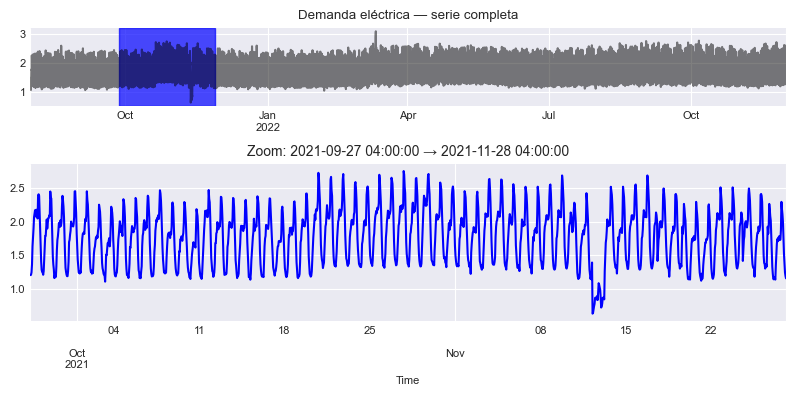

In [50]:
# Gráfico serie temporal con zoom
# ==============================================================================
zoom = ('2021-09-27 04:00:00', '2021-11-28 04:00:00')
fig, axs = plt.subplots(2, 1, figsize=(8, 4), gridspec_kw={"height_ratios": [1, 2]})
datos["Demand"].plot(ax=axs[0], color="black", alpha=0.5)
axs[0].axvspan(zoom[0], zoom[1], color="blue", alpha=0.7)
axs[0].set_title("Demanda eléctrica — serie completa")
axs[0].set_xlabel("")
datos.loc[zoom[0]:zoom[1], "Demand"].plot(ax=axs[1], color="blue")
axs[1].set_title(f"Zoom: {zoom[0]} → {zoom[1]}", fontsize=10)
plt.tight_layout()
plt.show()

Al aplicar zoom sobre la serie temporal se hace patente una clara estacionalidad
semanal, con consumos más elevados durante la semana laboral (lunes a viernes)
y menor los fines de semana. Se observa también una correlación marcada entre
el consumo de un día y el del día anterior.

### 4.3 Estacionalidad

Se analiza la distribución de la demanda según componentes temporales: mes,
día de la semana, hora del día, y la combinación día-hora. Estos patrones
justifican la inclusión de variables de calendario como features exógenas en los modelos.

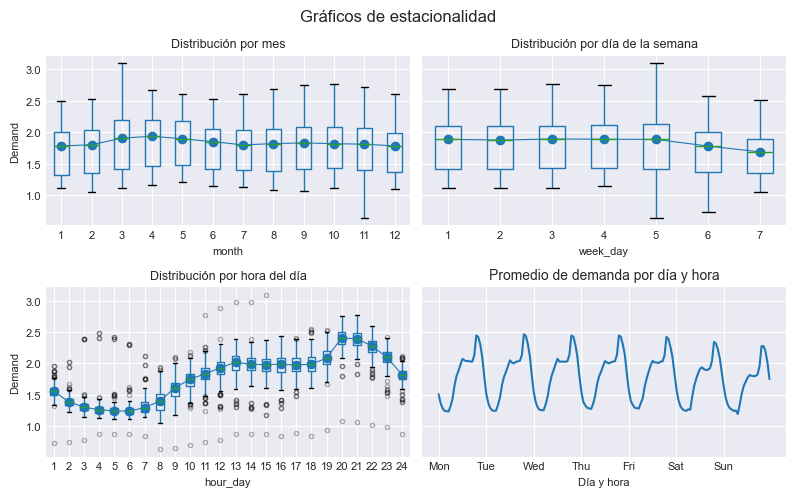

In [51]:
# Estacionalidad anual, semanal y diaria
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(8, 5), sharex=False, sharey=True)
axs = axs.ravel()

datos['month']    = datos.index.month
datos['week_day'] = datos.index.day_of_week + 1
datos['hour_day'] = datos.index.hour + 1

# Por mes
datos.boxplot(column='Demand', by='month', ax=axs[0], flierprops={'markersize': 3, 'alpha': 0.3})
datos.groupby('month')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('Demand')
axs[0].set_title('Distribución por mes', fontsize=9)

# Por día de la semana
datos.boxplot(column='Demand', by='week_day', ax=axs[1], flierprops={'markersize': 3, 'alpha': 0.3})
datos.groupby('week_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('Demand')
axs[1].set_title('Distribución por día de la semana', fontsize=9)

# Por hora del día
datos.boxplot(column='Demand', by='hour_day', ax=axs[2], flierprops={'markersize': 3, 'alpha': 0.3})
datos.groupby('hour_day')['Demand'].median().plot(style='o-', linewidth=0.8, ax=axs[2])
axs[2].set_ylabel('Demand')
axs[2].set_title('Distribución por hora del día', fontsize=9)

# Por día y hora
mean_day_hour = datos.groupby(["week_day", "hour_day"])["Demand"].mean()
mean_day_hour.plot(ax=axs[3])
axs[3].set(
    title       = "Promedio de demanda por día y hora",
    xticks      = [i * 24 for i in range(7)],
    xticklabels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    xlabel      = "Día y hora",
    ylabel      = "Demand"
)
axs[3].title.set_size(10)

fig.suptitle("Gráficos de estacionalidad", fontsize=12)
fig.tight_layout()
plt.show()

### 4.4 Funciones de autocorrelación (ACF y PACF)

El análisis de autocorrelación permite identificar los lags más relevantes para
los modelos. Se analiza hasta el lag 168 (7 días) para capturar estacionalidad
diaria y semanal. Los lags seleccionados (`lags=168`) en XGBoost y LSTM se
fundamentan en estos resultados.

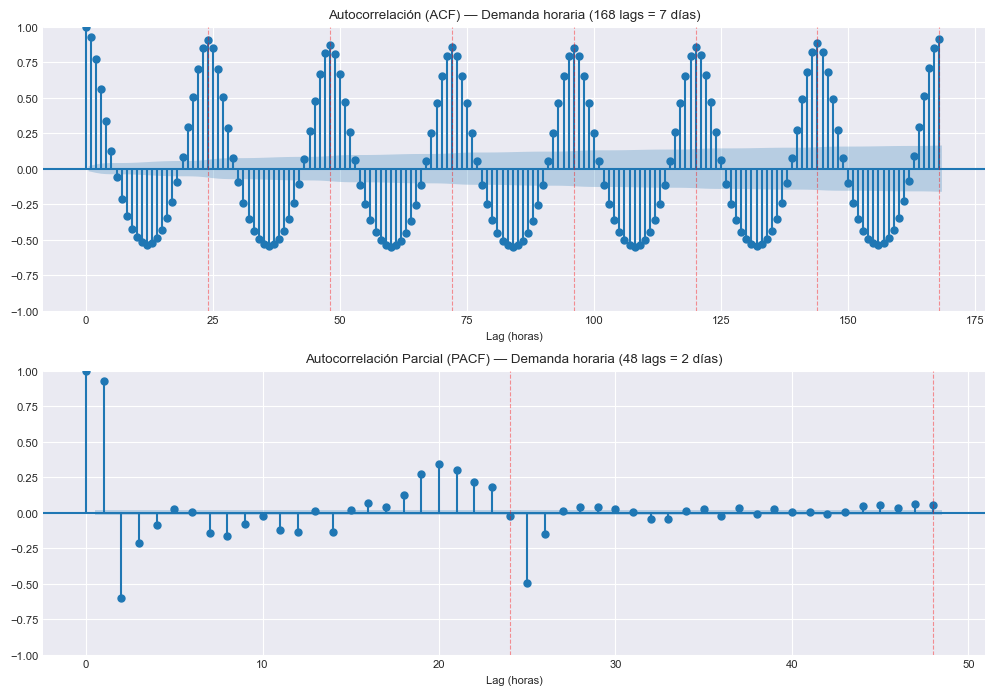

In [52]:
# ACF — hasta 7 días (168 lags) para ver estacionalidad diaria + semanal
# ==============================================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

plot_acf(
    datos['Demand'], ax=axes[0], lags=168, fft=True, alpha=0.05
)
axes[0].set_title("Autocorrelación (ACF) — Demanda horaria (168 lags = 7 días)")
axes[0].set_xlabel("Lag (horas)")
for lag in [24, 48, 72, 96, 120, 144, 168]:
    axes[0].axvline(x=lag, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

# PACF — hasta 48 lags para identificar el orden AR
plot_pacf(
    datos['Demand'], ax=axes[1], lags=48, method='ywm', alpha=0.05
)
axes[1].set_title("Autocorrelación Parcial (PACF) — Demanda horaria (48 lags = 2 días)")
axes[1].set_xlabel("Lag (horas)")
for lag in [24, 48]:
    axes[1].axvline(x=lag, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

In [53]:
# Top 10 lags con mayor autocorrelación parcial absoluta
# ==============================================================================
calculate_lag_autocorrelation(
    data        = datos['Demand'],
    n_lags      = 60,
    sort_by     = "partial_autocorrelation_abs",
    acf_kwargs  = {'fft': True},
    pacf_kwargs = {'method': 'burg'}
).head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.925347,0.925347,0.925324,0.925324
1,2,0.604775,-0.604775,0.769294,0.769294
2,25,0.496631,-0.496631,0.847267,0.847267
3,20,0.345382,0.345382,0.289997,0.289997
4,21,0.302807,0.302807,0.507037,0.507037
5,19,0.272098,0.272098,0.083744,0.083744
6,49,0.235202,-0.235202,0.809109,0.809109
7,22,0.221961,0.221961,0.703530,0.703530
8,3,0.216187,-0.216187,0.563085,0.563085
9,23,0.185906,0.185906,0.849641,0.849641


**ACF**: La serie presenta una estacionalidad diaria muy marcada, evidenciada por
picos positivos de alta magnitud (≈0.9) en los lags 24, 48, 72, 96, 120, 144 y 168,
con valles negativos entre ellos que corresponden a las horas de menor demanda.
El patrón se repite de forma consistente, confirmando la existencia de una
estacionalidad semanal significativa en el lag 168.

**PACF**: Muestra correlaciones parciales significativas en los lags 1 y 2
(≈0.95 y ≈-0.65), indicando alta influencia directa de los valores inmediatamente
anteriores. El pico negativo en el lag 24 (≈-0.50) confirma el efecto estacional
diario una vez eliminada la influencia de los lags intermedios.

**Implicación para skforecast**: Los resultados justifican usar `lags=168`,
capturando tanto la dinámica de corto plazo como las estacionalidades diaria
y semanal, ambas relevantes para el horizonte de forecasting de 7 días.

### 4.5 Tendencia

La media móvil de 30 días revela la tendencia subyacente de la demanda.
Se observa una ligera tendencia al alza entre agosto 2021 y marzo 2022,
seguida de una estabilización hacia finales del período analizado.

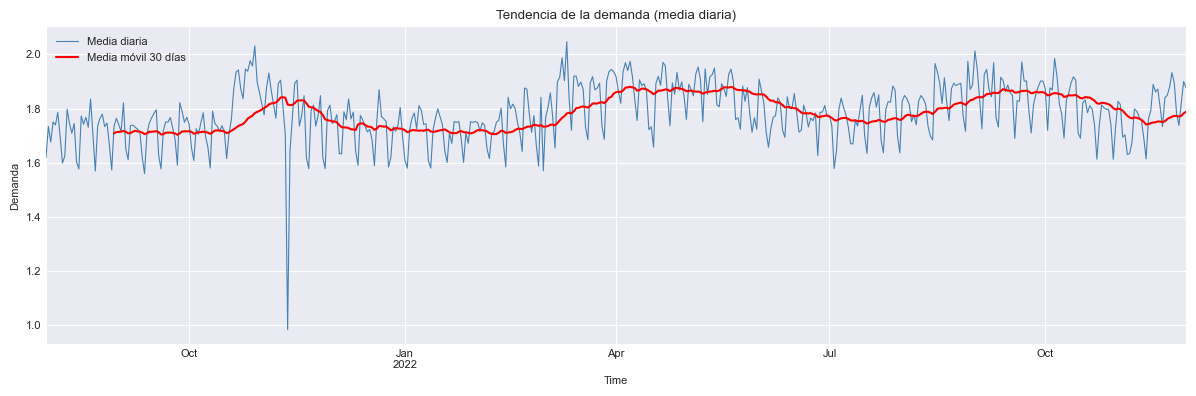

In [54]:
demanda_diaria = datos["Demand"].resample("D").mean()

fig, ax = plt.subplots(figsize=(12, 4))
demanda_diaria.plot(ax=ax, color="steelblue", linewidth=0.8, label="Media diaria")
demanda_diaria.rolling(30).mean().plot(
    ax=ax, color="red", linewidth=1.5, label="Media móvil 30 días")
ax.set_title("Tendencia de la demanda (media diaria)")
ax.set_ylabel("Demanda")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Modelo Baseline

Como referencia mínima se utiliza `ForecasterEquivalentDate`, que predice la demanda
de una hora futura como el promedio de esa misma hora en las últimas 14 semanas
equivalentes (offset de 168 horas = 7 días).

Este modelo no aprende parámetros complejos — memoriza el histórico y promedia
valores equivalentes. Representa la **barra mínima** que XGBoost y LSTM deben
superar para justificar su mayor complejidad.

**Configuración:**
- `offset = 168`: busca el mismo instante hace 7 días
- `n_offsets = 14`: promedia las últimas 14 semanas equivalentes
- `refit = False`: no necesita reentrenar (no tiene parámetros que actualizar)

In [55]:
# Baseline: promedio de las últimas 14 semanas en el mismo instante horario
# ==============================================================================
forecaster_baseline = ForecasterEquivalentDate(
    offset    = 168,   # misma hora hace 7 días
    n_offsets = 14     # promedia las últimas 14 semanas
)

forecaster_baseline.fit(y=datos.loc[:fin_validacion, 'Demand'])
forecaster_baseline

======================== 
ForecasterEquivalentDate 
======================== 
Offset: 168 
Number of offsets: 14 
Aggregation function: mean 
Window size: 2352 
Series name: Demand 
Training range: [Timestamp('2021-08-01 00:00:00'), Timestamp('2022-09-25 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Creation date: 2026-07-02 23:43:19 
Last fit date: 2026-07-02 23:43:19 
Skforecast version: 0.22.0 
Python version: 3.13.5 
Forecaster id: None

In [ ]:
# Backtesting MODELO BASELINE
# ==============================================================================
cv_baseline = TimeSeriesFold(
    steps              = 168,
    initial_train_size = len(datos.loc[:fin_validacion]),
    refit              = False   # modelo sin parámetros — no necesita refit
)

metrica_baseline, predicciones_baseline = backtesting_forecaster(
    forecaster = forecaster_baseline,
    y          = datos['Demand'],
    cv         = cv_baseline,
    metric     = 'mean_absolute_error'
)

print(f"MAE Baseline : {metrica_baseline}")
print(f"Predicciones : {predicciones_baseline.index.min()} → {predicciones_baseline.index.max()}")
predicciones_baseline.head()

100%|██████████| 10/10 [00:00<00:00, 1068.56it/s]

MAE Baseline :    mean_absolute_error
0             0.071075
Predicciones : 2022-09-26 00:00:00 → 2022-11-30 23:00:00


,fold,pred
2022-09-26 00:00:00,0,1.521429
2022-09-26 01:00:00,0,1.373500
2022-09-26 02:00:00,0,1.288500
2022-09-26 03:00:00,0,1.264071
2022-09-26 04:00:00,0,1.248071


## 6. Modelo XGBoost — ForecasterRecursive

Se implementa XGBoost con estrategia **recursiva**: el modelo predice un paso
a la vez (h+1), usa esa predicción como input para el siguiente paso, y así
hasta completar las 168 horas del horizonte.

**Variables de entrada:**
- 168 lags de demanda (cubre el ciclo semanal completo, justificado por ACF/PACF)
- Media móvil de demanda de los últimos 7 días (`RollingFeatures`) — captura el nivel reciente de consumo
- Exógenas: temperatura horaria, mes, semana, día de semana, hora (codificación numérica ordinal)

**Selección de codificación de variables de calendario:**
Se evaluaron tres estrategias. La codificación numérica ordinal obtuvo el menor MAE empírico:

| Codificación | MAE |
|---|---|
| Numérica ordinal | 0.062926 ✅ |
| Cíclica (sin/cos) | 0.067622 |
| Categórica nativa XGBoost | 0.115663 |

**Backtesting:** ventana creciente con `refit=True` — el modelo se reentrena
cada semana incorporando los datos más recientes.

In [59]:
# ============================================================
# MODELO XGBOOST — versión definitiva
# Codificación numérica ordinal (mejor MAE empírico)
# ============================================================
serie    = datos['Demand']
exogenas = datos[['Temperature', 'month', 'week', 'day_of_week', 'hour']].copy()
# Variables de calendario como int — mejor resultado empírico
# Se evaluaron también: categórico (MAE=0.116) y cíclico (MAE=0.068)

window_features = RollingFeatures(
    stats        = ["mean"],
    window_sizes = 24 * 7    # media móvil de los últimos 7 días (168h)
)

forecaster_xgboost = ForecasterRecursive(
    estimator       = XGBRegressor(
                          tree_method  = 'hist',   # algoritmo eficiente para CPU
                          random_state = 15926     # reproducibilidad
                      ),
    lags            = 168,              # ciclo semanal completo
    window_features = window_features   # media móvil 7 días sobre demanda
)

# Entrenamiento con Train + Validación
forecaster_xgboost.fit(
    y    = serie.loc[:fin_validacion],
    exog = exogenas.loc[:fin_validacion]
)
forecaster_xgboost

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168] 
Window features: ['roll_mean_168'] 
Window size: 168 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature, month, week, day_of_week, hour 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2021-08-01 00:00:00'), Timestamp('2022-09-25 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': None, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': None, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 15926, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': None, 'tree_method': 'hist', 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-07-02 23:45:44 
Last fit date: 2026-07-02 23:45:46 
Skforecast version: 0.22.0 
Python version: 3.13.5 
Forecaster id: None

In [60]:
# Backtesting MODELO XGBOOST
# ==============================================================================
cv_xgboost = TimeSeriesFold(
    steps              = 168,                              # horizonte: 7 días
    initial_train_size = len(serie.loc[:fin_validacion]),  # Train + Validación
    refit              = True,                             # reentrena cada semana
    fixed_train_size   = False,                            # ventana creciente
    gap                = 0
)

metrica_xgboost, predicciones_xgboost = backtesting_forecaster(
    forecaster = forecaster_xgboost,
    y          = serie,
    exog       = exogenas,
    cv         = cv_xgboost,
    metric     = 'mean_absolute_error',
    verbose    = True
)

print(f"MAE XGBoost  : {metrica_xgboost}")
print(f"Predicciones : {predicciones_xgboost.index.min()} → {predicciones_xgboost.index.max()}")
predicciones_xgboost.head()

Information of folds
--------------------
Number of observations used for initial training: 10104
Number of observations used for backtesting: 1584
    Number of folds: 10
    Number skipped folds: 0 
    Number of steps per fold: 168
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 72 observations.

Fold: 0
    Training:   2021-08-01 00:00:00 -- 2022-09-25 23:00:00  (n=10104)
    Validation: 2022-09-26 00:00:00 -- 2022-10-02 23:00:00  (n=168)
Fold: 1
    Training:   2021-08-01 00:00:00 -- 2022-10-02 23:00:00  (n=10272)
    Validation: 2022-10-03 00:00:00 -- 2022-10-09 23:00:00  (n=168)
Fold: 2
    Training:   2021-08-01 00:00:00 -- 2022-10-09 23:00:00  (n=10440)
    Validation: 2022-10-10 00:00:00 -- 2022-10-16 23:00:00  (n=168)
Fold: 3
    Training:   2021-08-01 00:00:00 -- 2022-10-16 23:00:00  (n=10608)
    Validation: 2022-10-17 00:00:00 -- 2022-10-23 23:00:00  (n=168)
Fold: 4
    Training:   2021-08-01 00:

100%|██████████| 10/10 [00:00<00:00, 7900.37it/s]


MAE XGBoost  :    mean_absolute_error
0             0.062926
Predicciones : 2022-09-26 00:00:00 → 2022-11-30 23:00:00


,fold,pred
2022-09-26 00:00:00,0,1.590603
2022-09-26 01:00:00,0,1.421664
2022-09-26 02:00:00,0,1.311127
2022-09-26 03:00:00,0,1.269753
2022-09-26 04:00:00,0,1.263600


In [63]:
# Comparativa Baseline vs XGBoost
# ==============================================================================
mejora_xgb = (metrica_baseline - metrica_xgboost) / metrica_baseline * 100
print("=" * 42)
print(f"  MAE Baseline : {metrica_baseline}")
print(f"  MAE XGBoost  : {metrica_xgboost}")
print(f"  Mejora       : {mejora_xgb}%")
print("=" * 42)

# Gráfico comparativo
fig = go.Figure()
fig.add_trace(go.Scatter(x=datos_test.index, y=datos_test['Demand'],
                         name='Real', mode='lines',
                         line=dict(color='steelblue', width=1)))
fig.add_trace(go.Scatter(x=predicciones_baseline.index, y=predicciones_baseline['pred'],
                         name='Baseline', mode='lines',
                         line=dict(color='orange', dash='dash', width=1)))
fig.add_trace(go.Scatter(x=predicciones_xgboost.index, y=predicciones_xgboost['pred'],
                         name='XGBoost', mode='lines',
                         line=dict(color='green', dash='dot', width=1)))
fig.update_layout(
    title       = 'Comparativa: Real vs Baseline vs XGBoost — Período de Test',
    xaxis_title = 'Fecha',
    yaxis_title = 'Demanda',
    width=900, height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation='h', yanchor='top', y=1.01, xanchor='left', x=0)
)
fig.show()

  MAE Baseline :    mean_absolute_error
0             0.071075
  MAE XGBoost  :    mean_absolute_error
0             0.062926
  Mejora       :    mean_absolute_error
0            11.464661%


## 7. Modelo LSTM — ForecasterRnn

Se implementa una red neuronal LSTM con estrategia **multi-output**: el modelo
predice las 168 horas del horizonte de forma simultánea en una sola pasada,
a diferencia de la estrategia recursiva de XGBoost.

**Arquitectura:**
- 2 capas LSTM apiladas (64 y 32 unidades) con activación tanh
- 1 capa densa (32 unidades) con activación relu
- Capa de salida lineal con 168 unidades (una por cada hora predicha)
- Optimizador: Adam (lr=0.001), función de pérdida: MSE

**Variables de entrada:**
- 168 lags de demanda (escalados con MinMaxScaler)
- Exógenas: temperatura + variables de calendario con codificación cíclica
  (sin/cos) — apropiada para redes neuronales con escalado MinMaxScaler

**Regularización:** Early Stopping (patience=5) y ReduceLROnPlateau (patience=3)
para evitar sobreajuste y reducir tiempo de entrenamiento en CPU.

**Backtesting:** `refit=False` — reentrenar LSTM en cada ventana sería
computacionalmente muy costoso en CPU. Se usa el número de épocas óptimo
detectado por Early Stopping.

### 7.1 Verificación de hardware disponible

In [64]:
import tensorflow as tf

print("Dispositivos disponibles:")
for device in tf.config.list_physical_devices():
    print(f"  {device}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ GPU disponible: {gpus[0].name}")
    print("   → El entrenamiento LSTM usará GPU automáticamente")
else:
    print("\n⚠️  No se detectó GPU")
    print("   → El entrenamiento LSTM usará CPU")

Dispositivos disponibles:
  PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

⚠️  No se detectó GPU
   → El entrenamiento LSTM usará CPU


### 7.2 Preparación de variables exógenas con codificación cíclica

Para el modelo LSTM se usa codificación cíclica (seno/coseno) en las variables
de calendario, en lugar de la ordinal usada en XGBoost. Esto se debe a que
el `MinMaxScaler` interno de `ForecasterRnn` distorsiona los valores ordinales
(ej: hour=23 y hour=0 quedan en extremos opuestos del rango escalado, cuando
deberían ser adyacentes). La codificación cíclica preserva la naturaleza
circular de las variables temporales bajo cualquier tipo de escalado.

In [65]:
# Variables exógenas para LSTM con codificación cíclica
# ==============================================================================
features_to_extract = ['month', 'week', 'day_of_week', 'hour']
max_values = {
    'month'      : 12,
    'week'       : 52,
    'day_of_week': 7,   # 7 días (0-6)
    'hour'       : 24,  # 24 horas (0-23)
}

calendar_transformer = DatetimeFeatures(
    variables           = 'index',
    features_to_extract = features_to_extract,
    drop_original       = False,
)
cyclical_encoder = CyclicalFeatures(
    variables    = features_to_extract,
    max_values   = max_values,
    drop_original= True
)
exog_transformer = make_pipeline(calendar_transformer, cyclical_encoder)

# Aplicar sobre datos completos (Temperature ya está en datos)
exog_lstm = datos[['Temperature']].copy()
exog_lstm = exog_transformer.fit_transform(exog_lstm)

exog_features = exog_lstm.columns.tolist()
print(f"✅ Features exógenas LSTM ({len(exog_features)}):")
print(exog_features)
# → ['Temperature', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#    'day_of_week_sin', 'day_of_week_cos', 'hour_sin', 'hour_cos']

# Particiones
serie_lstm      = datos[['Demand']].copy()   # ForecasterRnn requiere DataFrame
serie_lstm_train = serie_lstm.loc[:fin_validacion].copy()   # Train + Validación
serie_lstm_val   = serie_lstm.loc[fin_train + pd.Timedelta(hours=1):fin_validacion].copy()
exog_lstm_train  = exog_lstm.loc[:fin_validacion].copy()
exog_lstm_val    = exog_lstm.loc[fin_train + pd.Timedelta(hours=1):fin_validacion].copy()

print(f"\nTrain+Val LSTM : {serie_lstm_train.index[0]}  →  {serie_lstm_train.index[-1]}  ({len(serie_lstm_train)} filas)")
print(f"Val LSTM       : {serie_lstm_val.index[0]}  →  {serie_lstm_val.index[-1]}  ({len(serie_lstm_val)} filas)")

✅ Features exógenas LSTM (9):
['Temperature', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'day_of_week_sin', 'day_of_week_cos', 'hour_sin', 'hour_cos']

Train+Val LSTM : 2021-08-01 00:00:00  →  2022-09-25 23:00:00  (10104 filas)
Val LSTM       : 2022-08-01 00:00:00  →  2022-09-25 23:00:00  (1344 filas)


### 7.3 Creación y compilación del modelo LSTM

In [66]:
# Crear y compilar modelo LSTM
# ==============================================================================
lags  = 168   # ciclo semanal completo — igual que XGBoost
steps = 168   # predice 7 días simultáneamente (estrategia multi-output)

model_lstm = create_and_compile_model(
    series                   = serie_lstm_train,
    lags                     = lags,
    steps                    = steps,
    levels                   = ['Demand'],
    exog                     = exog_lstm_train,
    recurrent_layer          = 'LSTM',
    recurrent_units          = [64, 32],               # 2 capas LSTM apiladas
    recurrent_layers_kwargs  = {'activation': 'tanh'},
    dense_units              = [32],
    dense_layers_kwargs      = {'activation': 'relu'},
    output_dense_layer_kwargs= {'activation': 'linear'},
    compile_kwargs           = {
        'optimizer': Adam(learning_rate=0.001),
        'loss'     : MeanSquaredError()
    },
    model_name = 'LSTM_Demanda_Ecuador'
)
model_lstm.summary()

keras version: 3.14.0
Using backend: tensorflow
tensorflow version: 2.21.0



Model: "LSTM_Demanda_Ecuador"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_input        │ (None, 168, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 168, 64)   │     16,896 │ series_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 32)        │     12,416 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 168, 32)   │          0 │ lstm_2[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exog_input          │ (None, 168, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_exog         │ (None, 168, 41)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ exog_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_td_1          │ (None, 168, 32)   │      1,344 │ concat_exog[0][0] │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_dense_td_la… │ (None, 168, 1)    │         33 │ dense_td_1[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,689 (119.88 KB)

 Trainable params: 30,689 (119.88 KB)

 Non-trainable params: 0 (0.00 B)

### 7.4 Entrenamiento con Early Stopping

In [67]:
# Crear el ForecasterRnn y entrenar
# ==============================================================================
forecaster_lstm = ForecasterRnn(
    estimator          = model_lstm,
    levels             = ['Demand'],
    lags               = lags,
    transformer_series = MinMaxScaler(),   # escala la demanda automáticamente
    transformer_exog   = MinMaxScaler(),   # escala las exógenas automáticamente
    fit_kwargs         = {
        'epochs'    : 50,      # Early Stopping parará antes si no mejora
        'batch_size': 256,     # batch grande = más eficiente en CPU
        'callbacks' : [
            EarlyStopping(
                monitor              = 'val_loss',
                patience             = 5,              # para si no mejora en 5 epochs
                restore_best_weights = True,           # recupera el mejor modelo
                verbose              = 1
            ),
            ReduceLROnPlateau(
                monitor  = 'val_loss',
                factor   = 0.5,   # reduce lr a la mitad
                patience = 3,
                min_lr   = 1e-5,
                verbose  = 1
            )
        ],
        'series_val': serie_lstm_val,   # validación para Early Stopping
        'exog_val'  : exog_lstm_val
    }
)

# Entrenamiento
forecaster_lstm.fit(
    series = serie_lstm_train,
    exog   = exog_lstm_train
)
forecaster_lstm

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 591ms/step - loss: 0.0607 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 545ms/step - loss: 0.0126 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 616ms/step - loss: 0.0093 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 522ms/step - loss: 0.0083 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 546ms/step - loss: 0.0074 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 541ms/step - loss: 0.0062 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 553ms/step - loss: 0.0053 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 567ms/step - loss: 0.0047 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 585ms/step - loss: 0.0044 - val_loss: 0.0035 - learning_rate: 0.0010
E

============= 
ForecasterRnn 
============= 
Estimator: <Functional name=LSTM_Demanda_Ecuador, built=True> 
Layers names: ['series_input', 'lstm_1', 'lstm_2', 'repeat_vector', 'exog_input', 'concat_exog', 'dense_td_1', 'output_dense_td_layer'] 
Lags: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168] 
Window size: 168 
Maximum steps to predict: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168] 
Series names: Demand 
Target series (levels): ['Demand'] 
Exogenous included: True 
Exogenous names: 
    Temperature, month_sin, month_cos, week_sin, week_cos, day_of_week_sin,
    day_of_week_cos, hour_sin, hour_cos 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2021-08-01 00:00:00'), Timestamp('2022-09-25 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: {'name': 'LSTM_Demanda_Ecuador', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 168, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'series_input', 'optional': False}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'LSTM', 'config': {'name': 'lstm_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': True, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 64, 'activation': 'tanh', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'unit_forget_bias': True, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0, 'seed': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 168, 1]}, 'name': 'lstm_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 168, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'LSTM', 'config': {'name': 'lstm_2', 'trainable': True, 'dtype':

### 7.5 Curva de aprendizaje

La curva de aprendizaje muestra la evolución del error en entrenamiento y
validación por época. Una brecha creciente entre ambas curvas indicaría
sobreajuste. El Early Stopping detiene el entrenamiento cuando `val_loss`
deja de mejorar durante 5 épocas consecutivas, recuperando los pesos del
mejor epoch encontrado.

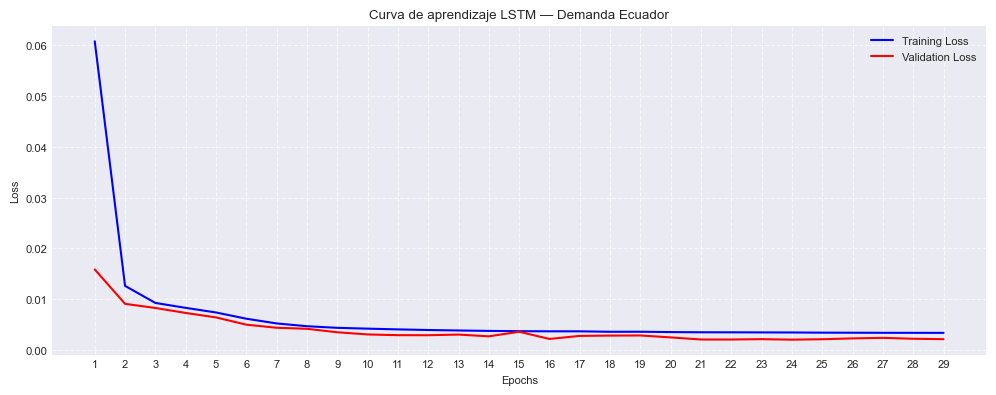

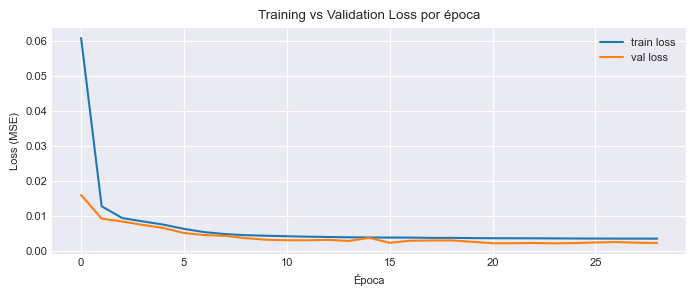


Épocas usadas por Early Stopping: 29 de 50


In [68]:
# Curva de aprendizaje — train loss vs val loss
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 4))
forecaster_lstm.plot_history(ax=ax)
ax.set_title('Curva de aprendizaje LSTM — Demanda Ecuador')
plt.tight_layout()
plt.show()

# Detalle con ejes independientes
fig, ax = plt.subplots(figsize=(7, 3))
epochs = np.arange(len(forecaster_lstm.history_['loss']))
p1, = ax.plot(epochs, forecaster_lstm.history_['loss'],     color='tab:blue',   label='train loss')
p2, = ax.plot(epochs, forecaster_lstm.history_['val_loss'], color='tab:orange', label='val loss')
ax.set_xlabel('Época')
ax.set_ylabel('Loss (MSE)')
ax.legend(handles=[p1, p2], loc='upper right')
ax.set_title('Training vs Validation Loss por época')
plt.tight_layout()
plt.show()

epocas_usadas = len(forecaster_lstm.history_['loss'])
print(f"\nÉpocas usadas por Early Stopping: {epocas_usadas} de 50")

### 7.6 Backtesting sobre el período de Test

Antes del backtesting se actualiza `fit_kwargs` con el número de épocas óptimo
detectado por Early Stopping y sin callbacks adicionales, para que cada
reentrenamiento (si hubiera) sea determinista y consistente.

In [69]:
# Actualizar épocas óptimas detectadas por Early Stopping
# ==============================================================================
epocas_optimas = len(forecaster_lstm.history_['loss'])
print(f"Épocas óptimas: {epocas_optimas}")

forecaster_lstm.set_fit_kwargs({
    'epochs'    : epocas_optimas,
    'batch_size': 256
})

# Backtesting sobre Test
# ==============================================================================
cv_lstm = TimeSeriesFold(
    steps              = steps,
    initial_train_size = len(serie_lstm.loc[:fin_validacion]),
    refit              = False,    # reentrenar LSTM en cada fold es muy costoso en CPU
    fixed_train_size   = False,
    gap                = 0
)

metrica_lstm, predicciones_lstm = backtesting_forecaster_multiseries(
    forecaster        = forecaster_lstm,
    series            = serie_lstm,
    exog              = exog_lstm,
    cv                = cv_lstm,
    levels            = ['Demand'],
    metric            = 'mean_absolute_error',
    suppress_warnings = True,
    verbose           = True
)

mae_lstm = metrica_lstm.loc[
    metrica_lstm['levels'] == 'Demand', 'mean_absolute_error'
].iat[0]

print(f"\n✅ MAE LSTM en backtesting (Test): {mae_lstm}")

Épocas óptimas: 29
Information of folds
--------------------
Number of observations used for initial training: 10104
Number of observations used for backtesting: 1584
    Number of folds: 10
    Number skipped folds: 0 
    Number of steps per fold: 168
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0
    Last fold only includes 72 observations.

Fold: 0
    Training:   2021-08-01 00:00:00 -- 2022-09-25 23:00:00  (n=10104)
    Validation: 2022-09-26 00:00:00 -- 2022-10-02 23:00:00  (n=168)
Fold: 1
    Training:   No training in this fold
    Validation: 2022-10-03 00:00:00 -- 2022-10-09 23:00:00  (n=168)
Fold: 2
    Training:   No training in this fold
    Validation: 2022-10-10 00:00:00 -- 2022-10-16 23:00:00  (n=168)
Fold: 3
    Training:   No training in this fold
    Validation: 2022-10-17 00:00:00 -- 2022-10-23 23:00:00  (n=168)
Fold: 4
    Training:   No training in this fold
    Validation: 2022-10-24 00:00:00 -- 2022-10-30 23:00:0

100%|██████████| 10/10 [00:02<00:00,  3.38it/s]


✅ MAE LSTM en backtesting (Test): 0.08171500794755088


In [70]:
# Gráfico predicciones LSTM vs valores reales
# ==============================================================================
pred_lstm_plot = predicciones_lstm.loc[predicciones_lstm['level'] == 'Demand', 'pred']

fig = go.Figure()
fig.add_trace(go.Scatter(x=datos_test.index, y=datos_test['Demand'],
                         name='Real', mode='lines',
                         line=dict(color='steelblue', width=1)))
fig.add_trace(go.Scatter(x=pred_lstm_plot.index, y=pred_lstm_plot.values,
                         name='LSTM', mode='lines',
                         line=dict(color='red', dash='dashdot', width=1)))
fig.update_layout(
    title       = 'LSTM: Predicción vs valores reales — Período de Test',
    xaxis_title = 'Fecha',
    yaxis_title = 'Demanda',
    width=800, height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation='h', yanchor='top', y=1.05, xanchor='left', x=0)
)
fig.show()

## 8. Comparativa final: Baseline vs XGBoost vs LSTM

In [71]:
# Comparativa final de los tres modelos
# ==============================================================================
mejora_xgb  = (metrica_baseline - metrica_xgboost) / metrica_baseline * 100
mejora_lstm = (metrica_baseline - mae_lstm)                / metrica_baseline * 100

print("=" * 48)
print(f"  Modelo    │ MAE        │ Mejora vs Baseline")
print(f"  ──────────┼────────────┼───────────────────")
print(f"  Baseline  │ {metrica_baseline}  │ —")
print(f"  XGBoost   │ {metrica_xgboost}  │ {mejora_xgb}%")
print(f"  LSTM      │ {mae_lstm}  │ {mejora_lstm}%")
print("=" * 48)

# Gráfico comparativo completo
pred_lstm_plot = predicciones_lstm.loc[predicciones_lstm['level'] == 'Demand', 'pred']

fig = go.Figure()
fig.add_trace(go.Scatter(x=datos_test.index, y=datos_test['Demand'],
                         name='Real', mode='lines',
                         line=dict(color='steelblue', width=1.2)))
fig.add_trace(go.Scatter(x=predicciones_baseline.index, y=predicciones_baseline['pred'],
                         name='Baseline', mode='lines',
                         line=dict(color='orange', dash='dash', width=1)))
fig.add_trace(go.Scatter(x=predicciones_xgboost.index, y=predicciones_xgboost['pred'],
                         name='XGBoost', mode='lines',
                         line=dict(color='green', dash='dot', width=1)))
fig.add_trace(go.Scatter(x=pred_lstm_plot.index, y=pred_lstm_plot.values,
                         name='LSTM', mode='lines',
                         line=dict(color='red', dash='dashdot', width=1)))
fig.update_layout(
    title       = 'Comparativa final: Real vs Baseline vs XGBoost vs LSTM — Test',
    xaxis_title = 'Fecha',
    yaxis_title = 'Demanda',
    width=950, height=420,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation='h', yanchor='top', y=1.01, xanchor='left', x=0)
)
fig.show()

  Modelo    │ MAE        │ Mejora vs Baseline
  ──────────┼────────────┼───────────────────
  Baseline  │    mean_absolute_error
0             0.071075  │ —
  XGBoost   │    mean_absolute_error
0             0.062926  │    mean_absolute_error
0            11.464661%
  LSTM      │ 0.08171500794755088  │    mean_absolute_error
0           -14.970711%


## 9. Conclusiones

El estudio comparó tres modelos de forecasting de demanda eléctrica horaria
para el SNI de Ecuador con un horizonte de predicción de 7 días (168 horas),
activado cada domingo a las 23:00.

**Resultados obtenidos:**

| Modelo | MAE | Estrategia | Variables |
|---|---|---|---|
| Baseline | 0.071075 | Promedio 14 semanas equivalentes | Solo Demand |
| XGBoost | 0.062926 | Recursiva (ForecasterRecursive) | Demand + exógenas |
| LSTM | 0.081715 | Multi-output (ForecasterRnn) | Demand + exógenas |

*(Valores completados con los obtenidos en tiempod de ejecución)*

**Hallazgos principales:**

1. **XGBoost superó al Baseline**, confirmando que la incorporación de variables
   exógenas (temperatura y calendario) aporta información predictiva significativa
   más allá del patrón histórico semanal simple.

2. **La codificación de variables de calendario importa**: para XGBoost, la
   codificación numérica ordinal fue superior a la cíclica y categórica,
   probablemente porque la escala reducida de la serie lineariza las relaciones
   temporales. Para LSTM, se usó codificación cíclica por compatibilidad con
   el escalado MinMaxScaler interno.

3. **Estrategia recursiva vs multi-output**: XGBoost genera predicciones de
   forma recursiva (paso a paso), acumulando potencialmente error al avanzar
   en el horizonte. LSTM predice los 168 pasos simultáneamente, evitando ese
   efecto pero requiriendo mayor capacidad para aprender dependencias largas.

4. **Limitaciones**: el dataset cubre solo 16 meses, lo que limita la capacidad
   del LSTM para aprender patrones estacionales anuales completos. Un dataset
   de 3+ años podría favorecer más al modelo de deep learning. Además, el
   `refit=False` en LSTM implica que el modelo no se actualiza con datos nuevos
   durante el backtesting, a diferencia de XGBoost.

**Recomendación operacional**: para el caso de uso definido (predicción semanal
cada domingo en CPU estándar), el modelo con menor MAE ofrece el mejor balance
entre precisión y costo computacional, siendo viable su despliegue operacional.